<a href="https://colab.research.google.com/github/princedanson/Intermidiate_1/blob/main/tutorials/test/Loan_prediction_problem_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
pd.set_option('future.no_silent_downcasting', True)

In [77]:
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")
loan_ds = pd.read_csv(os.path.join(path, "train_u6lujuX_CVtuZ9i.csv"))
loan_ds.head()

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [78]:
mapping = {
    "Female": 0,
    "Male": 1,
    "Graduate": 1,
    "Not Graduate": 0,
    "Urban": 1,
    "Rural": 0,
    "Semiurban": 2,  # Added mapping for 'Semiurban'
    'Yes': 1,
    "No": 0,
    "N": 0,
    "Y": 1,
    "0": 0, "1": 1, "2": 2, "3+": 3 # Added mapping for 'Dependents'
}
x_encode = loan_ds.replace(mapping)

# Explicitly convert 'Dependents' and 'Property_Area' to numeric after replacement
# Fill NaN values in 'Dependents' before converting to int
x_encode['Dependents'] = x_encode['Dependents'].fillna(x_encode['Dependents'].mode()[0]).astype(int)
x_encode['Property_Area'] = x_encode['Property_Area'].astype(int)

x_encode.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,NaN,360.0,1.0,1,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,1


In [79]:
Features_col_names = [col for col in loan_ds.columns if col not in ["Loan_ID", "Loan_Status"]]
target_col_name = "Loan_Status"

In [80]:
loan_x = x_encode[Features_col_names]
loan_y = x_encode[target_col_name]
loan_x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,1,0,5849,0.0,NaN,360.0,1.0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
610,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,0
611,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,1
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,1


 Gender Skewness:   -1.614968099460111
 Married Skewness:  -0.6369548086513567
 Dependents Skewness:    1.015550985536672
 Education Skewness:  -1.3676220101641772
 Self_Employed Skewness:    2.069692940668326
 ApplicantIncome Skewness:    6.539513113994625
 CoapplicantIncome Skewness:    7.491531216657306
 LoanAmount Skewness:    2.677551679256059
 Loan_Amount_Term Skewness:   -2.362414124216269
 Credit_History Skewness:  -1.8823610612186696
 Property_Area Skewness: -0.16281217598904912


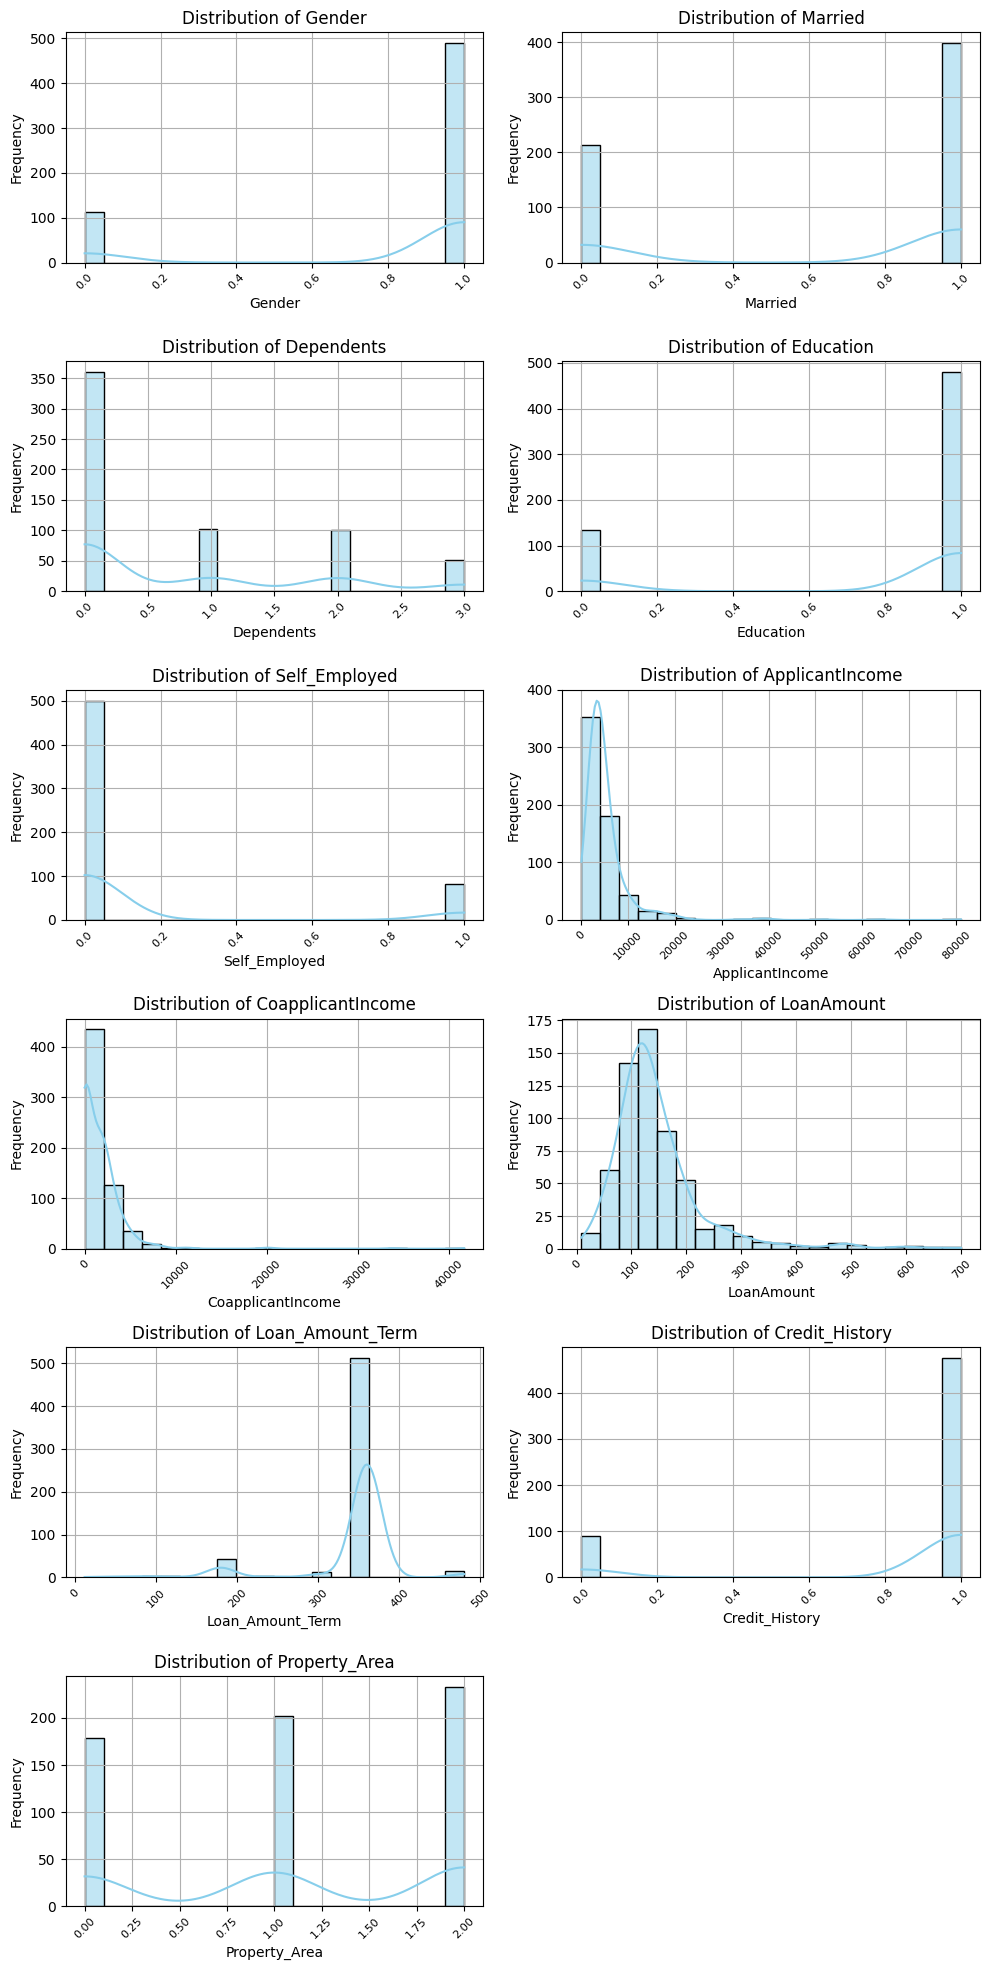

In [112]:
len_col = len(Features_col_names)
fig, axes = plt.subplots(nrows=(len_col+1)//2, ncols=2, figsize=(10, len_col*1.8))
axes = axes.flatten()
for i, col in enumerate(Features_col_names):
  skewness = loan_x[col].skew()
  print(f' {col :>.18} Skewness: {skewness:>20}')

  sns.histplot(data=loan_x, x=col, kde=True,ax=axes[i], color='skyblue', bins=20)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')
  axes[i].set_title(f'Distribution of {col}')
  axes[i].tick_params(axis='x', rotation=45,labelsize=8)
  axes[i].grid(True)

for i in range(len_col, len(axes)):
  fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

In [ ]:
loan_scaled = loan_x[Features_col_names]
for col in Features_col_names:
  loan_scaled[col] = (loan_x[col] - loan_x[col].mean()) / loan_x[col].std()
loan_scaled.head()